In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path(".../src").resolve()))

import json
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from conjunt_dades import ConjuntDadesDFFD
from model import ModelEspectreFase
from entrenament import (
    entrena_una_epoca,
    avalua,
    recull_prediccions,
    dibuixa_historic,
    dibuixa_matriu_confusio,
    dibuixa_corba_roc,
)

/opt/environment/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MIDA_IMATGE = (192, 192)
BATCH_SIZE = 16
EPOCHS = 20
LLAVOR = 42
LEARNING_RATE = 1e-3

NOM_EXPERIMENT = "FFHQ_FACEAPP"

RUTA_MANIFESTS = Path("/home/jms/FFD_CVPR2020/data_faceapp_ffhq/manifests")
ARREL_PROJECTE = Path("..").resolve()
RESULTATS = ARREL_PROJECTE / "resultats"
ruta_experiment = RESULTATS / NOM_EXPERIMENT
ruta_grafics = ruta_experiment / "grafics"

RESULTATS.mkdir(exist_ok=True)
ruta_experiment.mkdir(parents=True, exist_ok=True)
ruta_grafics.mkdir(exist_ok=True)

In [3]:
df_train = pd.read_csv(RUTA_MANIFESTS / "train.csv")
df_val = pd.read_csv(RUTA_MANIFESTS / "val.csv")
df_test = pd.read_csv(RUTA_MANIFESTS / "test.csv")

print(len(df_train), len(df_val), len(df_test))
print(df_train["label"].value_counts())
print(df_val["label"].value_counts())
print(df_test["label"].value_counts())

12618 1998 9002
label
0    6309
1    6309
Name: count, dtype: int64
label
0    999
1    999
Name: count, dtype: int64
label
0    4501
1    4501
Name: count, dtype: int64


In [4]:
train_dataset = ConjuntDadesDFFD(df_train, mida=MIDA_IMATGE)
val_dataset = ConjuntDadesDFFD(df_val, mida=MIDA_IMATGE)
test_dataset = ConjuntDadesDFFD(df_test, mida=MIDA_IMATGE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
model = ModelEspectreFase().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

historic = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": []
}

In [6]:
for epoch in range(EPOCHS):
    train_loss = entrena_una_epoca(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_metrics = avalua(model, val_loader, criterion, DEVICE)

    historic["train_loss"].append(train_loss)
    historic["val_loss"].append(val_loss)
    historic["val_accuracy"].append(val_metrics["accuracy"])
    historic["val_precision"].append(val_metrics["precision"])
    historic["val_recall"].append(val_metrics["recall"])
    historic["val_f1"].append(val_metrics["f1"])
    historic["val_auc"].append(val_metrics["auc"])

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val loss:   {val_loss:.4f}")
    print(f"  Val acc:    {val_metrics['accuracy']:.4f}")
    print(f"  Val f1:     {val_metrics['f1']:.4f}")
    print(f"  Val auc:    {val_metrics['auc']}")

Epoch 1/20
  Train loss: 0.5805
  Val loss:   0.5158
  Val acc:    0.7543
  Val f1:     0.7286
  Val auc:    0.8095142189236283
Epoch 2/20
  Train loss: 0.5289
  Val loss:   0.5029
  Val acc:    0.7618
  Val f1:     0.7463
  Val auc:    0.8174981788595402
Epoch 3/20
  Train loss: 0.5218
  Val loss:   0.5273
  Val acc:    0.7212
  Val f1:     0.7501
  Val auc:    0.8280101923745566
Epoch 4/20
  Train loss: 0.5207
  Val loss:   0.4979
  Val acc:    0.7633
  Val f1:     0.7558
  Val auc:    0.839885430976522
Epoch 5/20
  Train loss: 0.5132
  Val loss:   0.4935
  Val acc:    0.7693
  Val f1:     0.7531
  Val auc:    0.8465632799967134
Epoch 6/20
  Train loss: 0.5117
  Val loss:   0.5016
  Val acc:    0.7513
  Val f1:     0.7607
  Val auc:    0.8472376280184089
Epoch 7/20
  Train loss: 0.5090
  Val loss:   0.4879
  Val acc:    0.7653
  Val f1:     0.7586
  Val auc:    0.8517366215063914
Epoch 8/20
  Train loss: 0.4989
  Val loss:   0.4867
  Val acc:    0.7788
  Val f1:     0.7439
  Val auc:

In [7]:
test_loss, test_metrics = avalua(model, test_loader, criterion, DEVICE)

print("Resultats finals en test")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"AUC:       {test_metrics['auc']}")

Resultats finals en test
Loss:      0.4295
Accuracy:  0.7997
Precision: 0.8822
Recall:    0.6918
F1:        0.7755
AUC:       0.8875312509239719


In [8]:
y_true, y_prob, y_pred = recull_prediccions(model, test_loader, DEVICE)

df_prediccions = df_test.reset_index(drop=True).copy()
df_prediccions["y_true"] = y_true
df_prediccions["y_prob"] = y_prob
df_prediccions["y_pred"] = y_pred

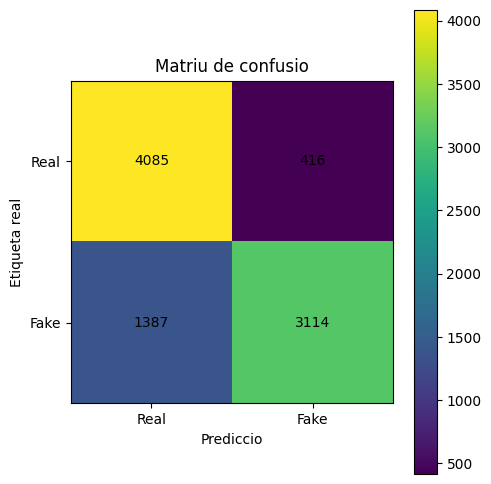

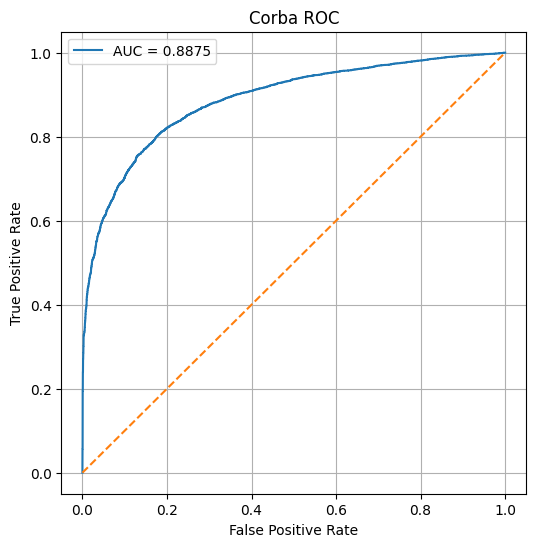

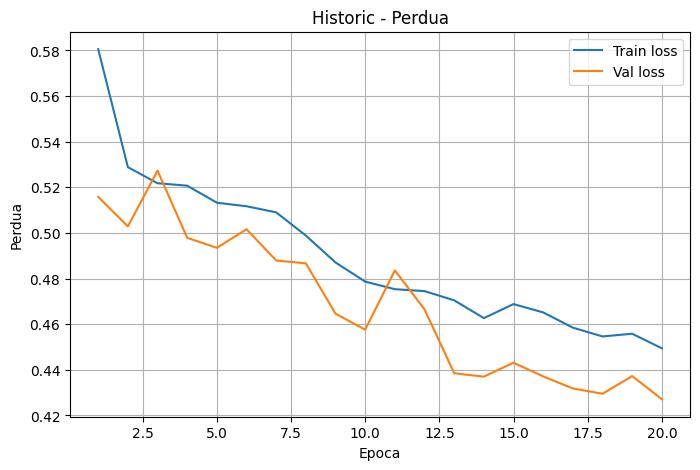

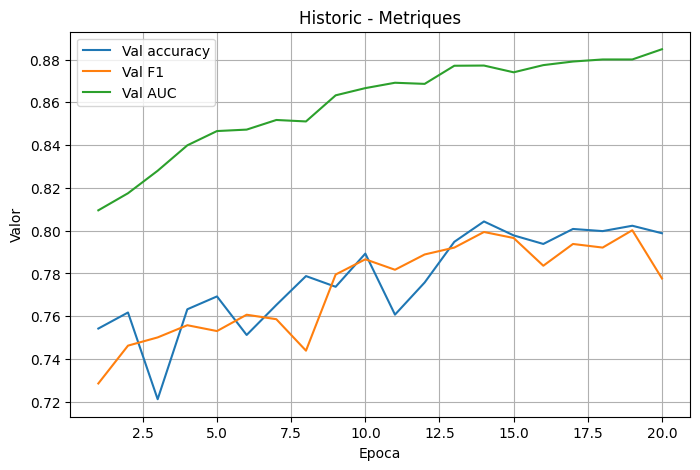

In [9]:
dibuixa_matriu_confusio(
    y_true,
    y_pred,
    titol="Matriu de confusio",
    ruta=ruta_grafics
)

dibuixa_corba_roc(
    y_true,
    y_prob,
    titol="Corba ROC",
    ruta=ruta_grafics
)

dibuixa_historic(
    historic,
    titol="Historic",
    ruta=ruta_grafics
)

metriques = {
    "Nom experiment": NOM_EXPERIMENT,
    "Metode fake": "faceapp",
    "Seed": LLAVOR,
    "Num epoques": EPOCHS,
    "Batch size": BATCH_SIZE,
    "Learning rate": LEARNING_RATE,
    "Mida imatge": list(MIDA_IMATGE),
    "Device": DEVICE,
    "Train size": len(df_train),
    "Val size": len(df_val),
    "Test size": len(df_test),
    "Test loss": test_loss,
    "Metriques": test_metrics,
    "Historic": historic
}

ruta_metriques = ruta_experiment / "metriques.json"
with open(ruta_metriques, "w", encoding="utf-8") as fitxer:
    json.dump(metriques, fitxer, indent=4)

ruta_model = ruta_experiment / "model.pth"
torch.save(model.state_dict(), ruta_model)

ruta_prediccions = ruta_experiment / "prediccions.csv"
df_prediccions.to_csv(ruta_prediccions, index=False)